# Apprentissage supervisé
# Arbre de Décision : Prédiction du Prix des Voitures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [2]:
# Chargement du dataset
df = pd.read_csv("car_prices_Pretraite.csv", header=0)

# Aperçu
print(df.head())
df.shape

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    suv    automatic   
1  2015    Kia              Sorento          LX    suv    automatic   
2  2014    Bmw             3 Series  328i SULEV  sedan    automatic   
3  2015  Volvo                  S60          T5  sedan    automatic   
4  2014    Bmw  6 Series Gran Coupe        650i  sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

(548498, 16)

In [3]:
# Création de la variable cible : catégorie de prix
# Bas  : sellingprice < 10 000 $
# Moyen: 10 000 $ ≤ sellingprice < 20 000 $
# Haut : sellingprice ≥ 20 000 $
bins   = [0, 10000, 20000, float('inf')]
labels = ['Bas', 'Moyen', 'Haut']
df['price_category'] = pd.cut(df['sellingprice'], bins=bins, labels=labels)

df['price_category'].value_counts()

price_category
Moyen    229193
Bas      209085
Haut     110220
Name: count, dtype: int64

In [4]:
# Sélection des variables explicatives numériques
X = df[['year', 'condition', 'odometer', 'mmr']].dropna()
y = df.loc[X.index, 'price_category']

# Suppression des lignes où la cible est NaN
mask = y.notna()
X = X[mask]
y = y[mask]

print(f"Taille de X : {X.shape}")
print(f"Répartition des classes :\n{y.value_counts()}")

Taille de X : (548498, 4)
Répartition des classes :
price_category
Moyen    229193
Bas      209085
Haut     110220
Name: count, dtype: int64


In [5]:
# Division 80 % entraînement / 30 % test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

print(f"Entraînement : {X_train.shape}")
print(f"Test         : {X_test.shape}")

Entraînement : (438798, 4)
Test         : (109700, 4)


In [6]:
# Arbre de décision avec entropie
clf = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [7]:
# Affichage de l'importance des attributs
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

mmr          0.977309
condition    0.021306
year         0.001210
odometer     0.000174
dtype: float64

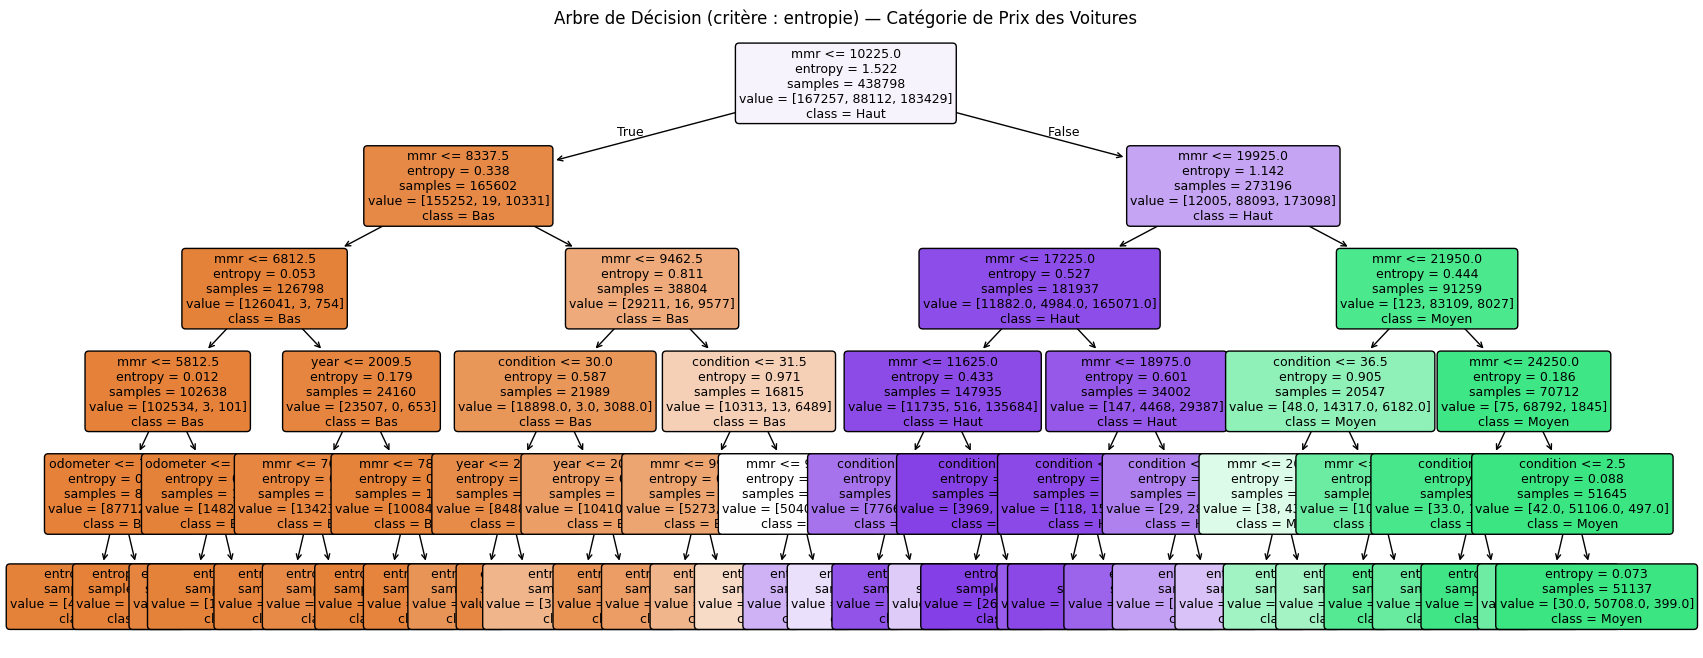

In [8]:
plt.figure(figsize=(20, 8))
plot_tree(
    clf,
    filled=True,
    feature_names=X.columns,
    class_names=['Bas', 'Moyen', 'Haut'],
    rounded=True,
    fontsize=9
)
plt.title("Arbre de Décision (critère : entropie) — Catégorie de Prix des Voitures")
plt.show()

In [9]:
# Prédiction sur le jeu de test
y_pred = clf.predict(X_test)

# Rapport de classification
print(classification_report(y_test, y_pred, target_names=['Bas', 'Moyen', 'Haut']))

              precision    recall  f1-score   support

         Bas       0.95      0.92      0.93     41828
       Moyen       0.93      0.93      0.93     22108
        Haut       0.89      0.92      0.91     45764

    accuracy                           0.92    109700
   macro avg       0.92      0.92      0.92    109700
weighted avg       0.92      0.92      0.92    109700



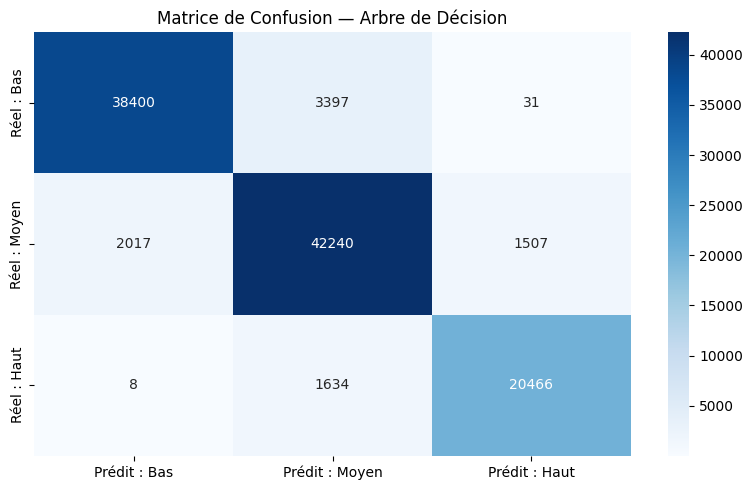

In [10]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred, labels=['Bas', 'Moyen', 'Haut'])
cm_df = pd.DataFrame(cm,
                     index=['Réel : Bas', 'Réel : Moyen', 'Réel : Haut'],
                     columns=['Prédit : Bas', 'Prédit : Moyen', 'Prédit : Haut'])

plt.figure(figsize=(8, 5))
import seaborn as sns
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title("Matrice de Confusion — Arbre de Décision")
plt.tight_layout()
plt.show()

## ✅ Résumé

- L'algorithme utilise **l'entropie** pour mesurer l'homogénéité des données à chaque nœud.
- À chaque étape, il choisit la **caractéristique qui maximise le gain d'information**.
- La variable **mmr** (Manheim Market Report) est la plus influente pour prédire la catégorie de prix, suivie de l'**odometer** et de l'**year**.
- La visualisation permet de comprendre facilement les règles de décision utilisées pour classifier les véhicules en **Bas**, **Moyen** ou **Haut**.